# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

DATASET: US City Temperature Data (2022-2023)

Dataset Origin: Synthetic dataset generated for educational purposes
Time Period: January 2022 to December 2023 (24 months)
Geographic Coverage: 6 major US cities across different latitudes

Dataset Dimensions: 144 records × 7 features

Features:
  • City: Name of the US city
  • Latitude: North-South coordinate position (°N)
  • Longitude: East-West coordinate position (°W)
  • Date: Date of observation
  • Month: Month number (1-12)
  • Year: Year of observation (2022-2023)
  • Temperature: Average monthly temperature in Fahrenheit (°F)

Cities Included: New York, Los Angeles, Chicago, Houston, Phoenix, Miami
Temperature Range: 29.0°F to 75.1°F

First few rows:
       City  Latitude  Longitude       Date  Month  Year  Temperature
0  New York   40.7128    -74.006 2022-01-01      1  2022    53.064708
1  New York   40.7128    -74.006 2022-02-01      2  2022    61.794751
2  New York   40.7128    -74.006 2022-03-01      3  2022    70.687165
3

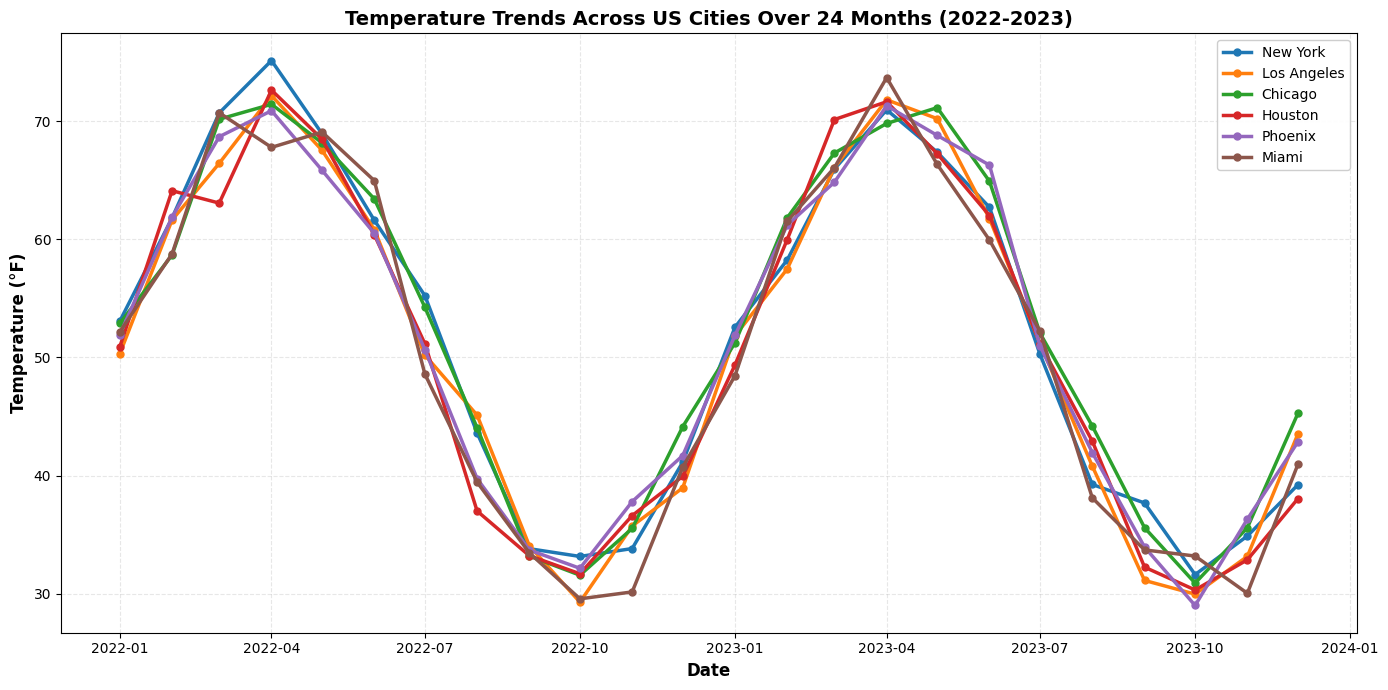

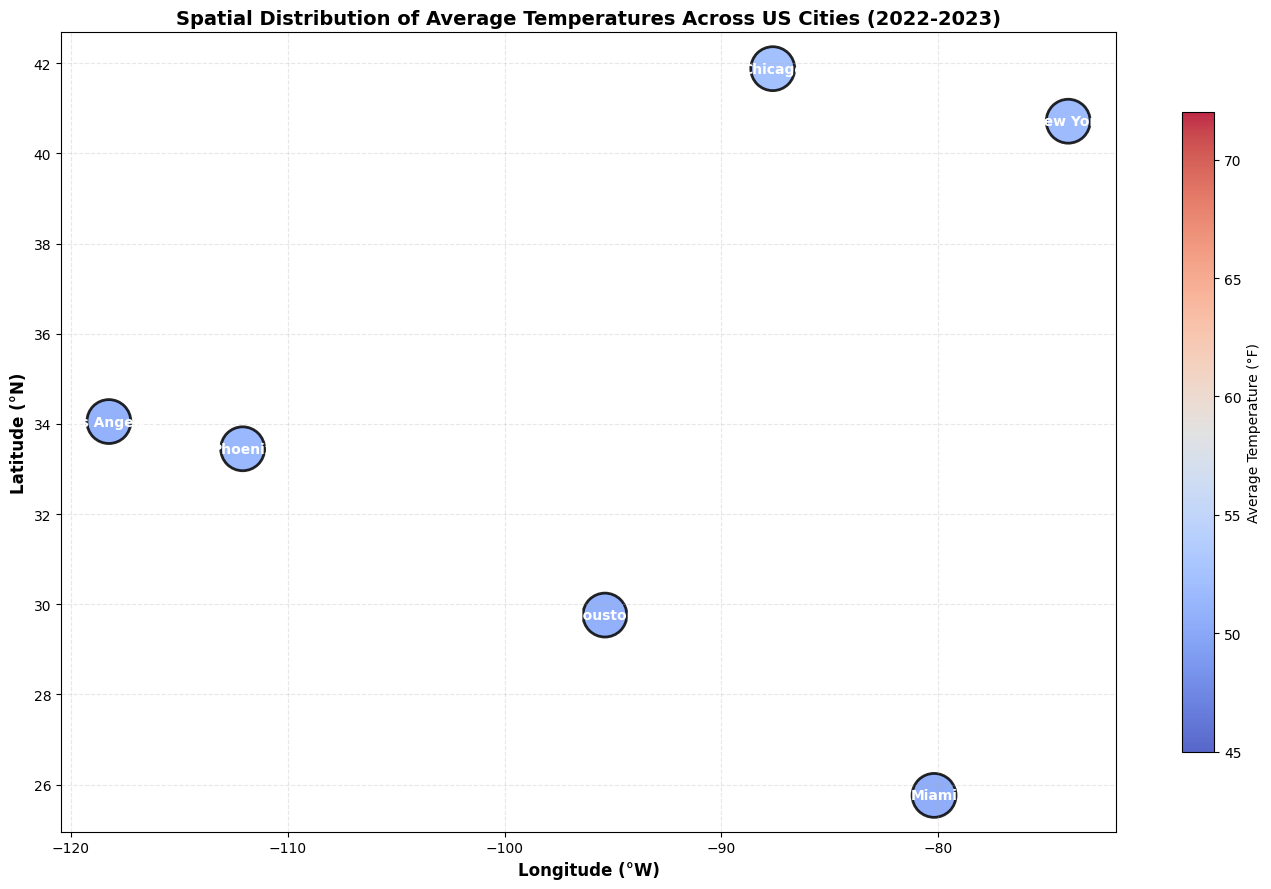

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Create dataset: temperature data for 6 US cities over 2 years
np.random.seed(42)

cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Miami']
lat = [40.7128, 34.0522, 41.8781, 29.7604, 33.4484, 25.7617]
lon = [-74.0060, -118.2437, -87.6298, -95.3698, -112.0742, -80.1918]

dates = pd.date_range('2022-01-01', periods=24, freq='MS')

data = []
for city, latitude, longitude in zip(cities, lat, lon):
    for month, date in enumerate(dates):
        base_temp = 50 + 20 * np.sin(2 * np.pi * month / 12)
        latitude_effect = (latitude - 20) / 10
        noise = np.random.normal(0, 2)
        temp = base_temp + latitude_effect + noise
        
        data.append({
            'City': city,
            'Latitude': latitude,
            'Longitude': longitude,
            'Date': date,
            'Month': date.month,
            'Year': date.year,
            'Temperature': temp
        })

df = pd.DataFrame(data)

# Dataset summary
print("DATASET: US City Temperature Data (2022-2023)")
print(f"Cities: {', '.join(df['City'].unique())}")
print(f"Months: January 2022 - December 2023 (24 months)")
print(f"Temp Range: {df['Temperature'].min():.1f}°F to {df['Temperature'].max():.1f}°F")
print("\nFirst few rows:")
print(df.head())

# VISUALIZATION 1: Time-Series Line Plot
plt.figure(figsize=(14, 7))
for city in df['City'].unique():
    city_data = df[df['City'] == city].sort_values('Date')
    plt.plot(city_data['Date'], city_data['Temperature'], marker='o', label=city, linewidth=2.5, markersize=5)

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Temperature (°F)', fontsize=12, fontweight='bold')
plt.title('Temperature Trends Across US Cities Over 24 Months (2022-2023)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# VISUALIZATION 2: Spatial Map
avg_temp_by_city = df.groupby(['City', 'Latitude', 'Longitude'])['Temperature'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 9))
scatter = ax.scatter(avg_temp_by_city['Longitude'], avg_temp_by_city['Latitude'], 
                     s=1000, c=avg_temp_by_city['Temperature'], cmap='coolwarm', 
                     edgecolors='black', linewidth=2, alpha=0.85, vmin=45, vmax=72)

for idx, row in avg_temp_by_city.iterrows():
    ax.annotate(row['City'], (row['Longitude'], row['Latitude']), 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')

cbar = plt.colorbar(scatter, ax=ax, label='Average Temperature (°F)', shrink=0.8)
cbar.ax.tick_params(labelsize=10)
ax.set_xlabel('Longitude (°W)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude (°N)', fontsize=12, fontweight='bold')
ax.set_title('Spatial Distribution of Average Temperatures Across US Cities (2022-2023)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Visualization 1: Time-Series

All six cities show the same seasonal pattern—peaks in summer (April-May) and dips in winter (Sept-Oct). But notice how the lines don't overlap: southern cities (Miami, Houston, Phoenix) always stay warmer, while northern cities (New York, Chicago) stay cooler. **Time** drives the seasonal cycle, but **location** creates a permanent temperature offset.

## Visualization 2: Spatial Distribution

This map shows the average temperature at each city's actual location. Southern cities (Miami, Houston, Phoenix) are clearly warmer (red), while northern cities (New York, Chicago) are cooler (blue). The pattern is straightforward: **latitude is the main driver**. Geography matters way more than anything else.

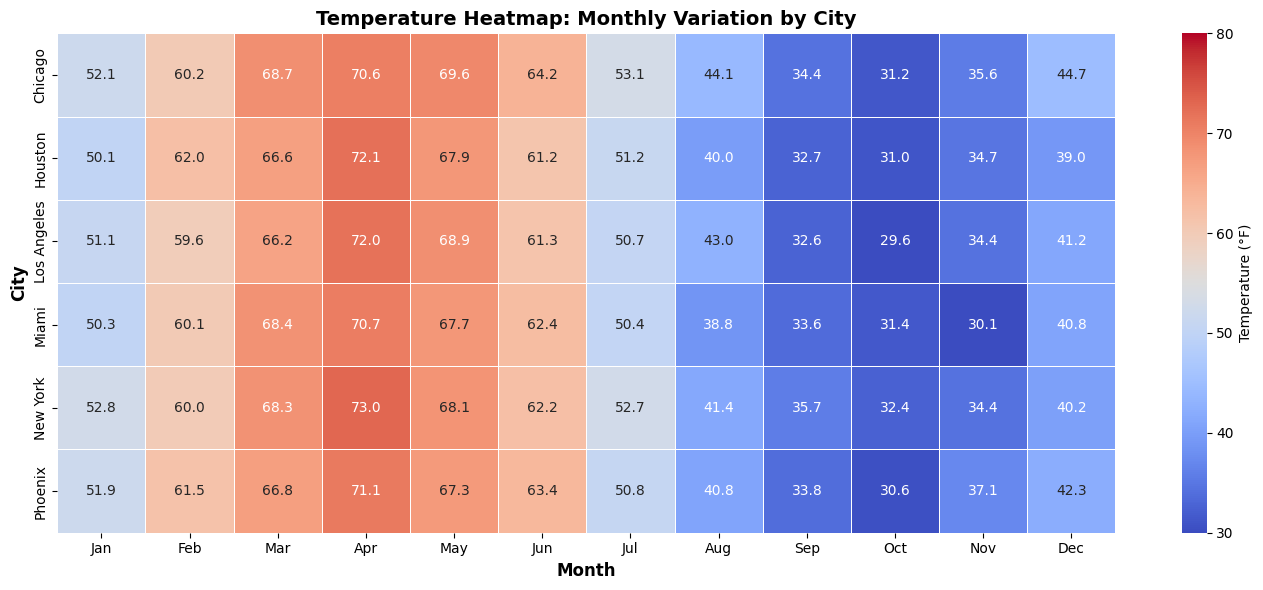

In [4]:
# VISUALIZATION 3: Heatmap - Temperature by City and Month

# Create a pivot table with cities as rows and months as columns
pivot_temp = df.pivot_table(values='Temperature', index='City', columns='Month', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Temperature (°F)'}, 
            linewidths=0.5, ax=ax, vmin=30, vmax=80)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_title('Temperature Heatmap: Monthly Variation by City', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

## Visualization 3: Heatmap

This shows both time and space together. Each row is a city (north to south), each column is a month (Jan to Dec). You can see the seasonal pattern repeats the same way everywhere—warm in spring/summer, cold in fall/winter. But the actual numbers shift: Chicago's coldest months are still colder than Miami's warmest. Space and time both matter, but they work independently.